<a href="https://colab.research.google.com/github/marioguerrerosalah/ANALITICA-DE-NEGOCIOS/blob/main/TALLER_1_ANALITICA_DE_NEGOCIOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd # brinda estructura a los datos como un dataframe
import numpy as np # Me premite hacer operaciones matematicas
import matplotlib.pyplot as plt # El graficador base de python. Me permite graficar y personalizar graficas
import seaborn as sns # graficas mas bonitas

In [ ]:
##punto 1

ruta="/content/base carros.xlsx"
base=pd.read_excel(ruta)

In [ ]:
##punto 2

base.shape ## me muestra la dimension del dataframe
base.head() #me muestra los primeros datos
base.dtypes #int64: numeros enteros objetcs: texto. STR: texto casi no hay diferencia con object Float64: numeros decimales
base.info() # me mda informacion de la base de datos. si hay vacios y el tipo de datos
base.columns # por si se olivda el  nombre de alguna variable los buscas con este codigo y lo encuentras

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9655 entries, 0 to 9654
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                9655 non-null   int64  
 1   make                9649 non-null   object 
 2   model               9655 non-null   object 
 3   city                9654 non-null   object 
 4   state               9655 non-null   object 
 5   mileage             9652 non-null   float64
 6   price               9652 non-null   float64
 7   exterior_color      9650 non-null   object 
 8   mpg_city            9655 non-null   object 
 9   mpg_hwy             9247 non-null   float64
 10  engine              9655 non-null   object 
 11  transmission        9655 non-null   object 
 12  drive_type          9655 non-null   object 
 13  fuel_type           9652 non-null   object 
 14  reported accidents  9655 non-null   int64  
 15  cpo                 9651 non-null   object 
dtypes: flo

In [ ]:
#punto 3


#borrar vacios

base.isnull().sum()
# variable make 6 vacios
#variable city 1 vacio
#variable mileage 3 vacios
#variable price 3 vacios
#variable exterior_color 5 vacios
#variable mpg_hwy 408 vacios
#variable fuel_type 3 vacios
#variable cpo 4 vacios
base2=base.dropna()
base2.isnull().sum() # esta nueva base llamada "base2" ya no tiene vacios

#borrar duplicados
base.duplicated().sum() #hay 3 duplicados en la base de datos
base2=base.drop_duplicates()
base2.duplicated().sum()# esta nueva base ya no tiene datos duplicados

0

In [ ]:
#punto 4

base2.info() # como se puede ver aca la variable CPO es de dtype "object"
base2['cpo']=base2['cpo'].astype('category') #con esta formula le cambiamos el dtype a la variable de object a category
base2.dtypes #aqui podemos evidenciar el cambio

<class 'pandas.core.frame.DataFrame'>
Index: 9652 entries, 0 to 9654
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                9652 non-null   int64  
 1   make                9646 non-null   object 
 2   model               9652 non-null   object 
 3   city                9651 non-null   object 
 4   state               9652 non-null   object 
 5   mileage             9649 non-null   float64
 6   price               9649 non-null   float64
 7   exterior_color      9647 non-null   object 
 8   mpg_city            9652 non-null   object 
 9   mpg_hwy             9245 non-null   float64
 10  engine              9652 non-null   object 
 11  transmission        9652 non-null   object 
 12  drive_type          9652 non-null   object 
 13  fuel_type           9649 non-null   object 
 14  reported accidents  9652 non-null   int64  
 15  cpo                 9648 non-null   object 
dtypes: float64(

<ipython-input-67-ce9838fb5823>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base2['cpo']=base2['cpo'].astype('category') #con esta formula le cambiamos el dtype a la variable de object a category


,0
year,int64
make,object
model,object
city,object
state,object
mileage,float64
price,float64
exterior_color,object
mpg_city,object
mpg_hwy,float64


In [ ]:
#punto 5

base2['city'].value_counts() #como podemos ver, la ciudad que mas carros hay en la base de datos es houston con 166 carros en su ciudad
base2["make"].value_counts() #la marca de carro que mas frecuenta en la base de datos es Ford con 2408
base2['transmission'].value_counts() # se puede evidenciar que en la base de datos se prefiere el carro automatico, ya que 9369 carros son automaicos a diferencia de 283 que son manuales

,count
transmission,
Automatic,9369
Manual,283


In [ ]:
#punto 6


from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


base2["transmission2"]=le.fit_transform(base2["transmission"])
base2["city2"]=le.fit_transform(base2["city"])
base2["make2"]=le.fit_transform(base2["make"])
base2.head() # se crearon nuevas variables convertidas a numericas

print(base2["transmission"].value_counts())
print(base2["transmission2"].value_counts())

print(base2["city"].value_counts())
print(base2["city2"].value_counts())

print(base2["make"].value_counts())
print(base2["make2"].value_counts())

base3=base2[['year', 'make', 'model', 'city', 'state', 'mileage', 'price',
       'exterior_color', 'mpg_city', 'mpg_hwy', 'engine', 'transmission',
       'drive_type', 'fuel_type', 'reported accidents', 'cpo', 'transmission2',
       'city2', 'make2']] # convertirmos esto a una nueva base llamada base 3


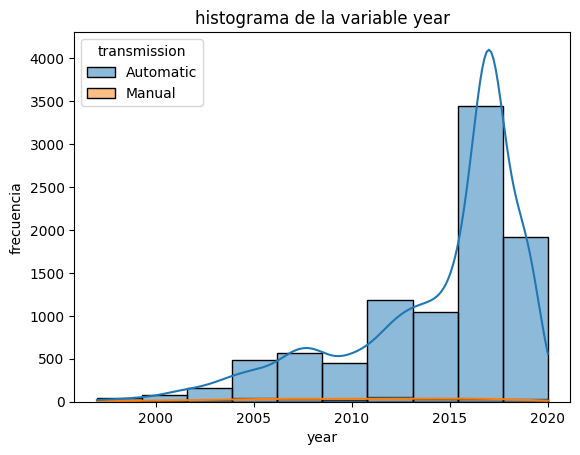

In [ ]:
#punto 7



base3.describe()
base3["year"].mean() # la media es de 2014.1827600497306
base3["year"].std() #la desviacion estandar es de 4.6018517812762285
base3["year"].median() # la mediana es de 2016.0
base3["year"].min() # el carro mas antiguo es del año 1997
base3["year"].max() #el carro mas moderno es del 2020


sns.histplot(x="year", data=base3,bins=10,kde=True,hue="transmission")
plt.title("histograma de la variable year")
plt.xlabel("year")
plt.ylabel("frecuencia")
plt.show()

# Lo que nos muestra este histograma es que entre 2015 y 2020 hubo una frecuencia mucho mas alta en los carros automaticos en comparacion a los años anteriores.

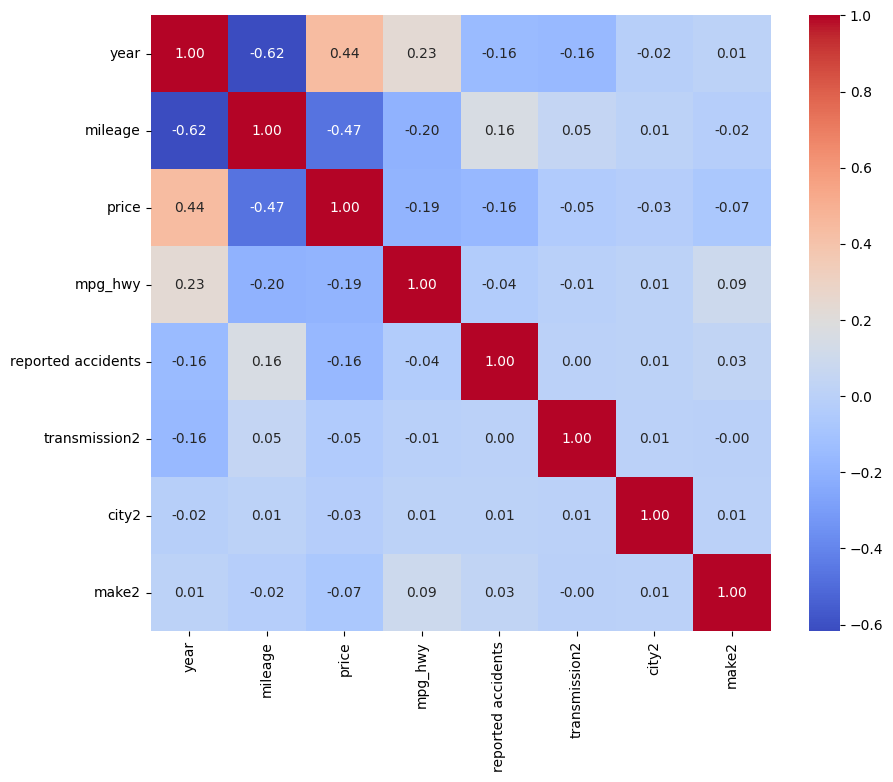

In [ ]:
#punto 8

base3.dtypes
x=base3[["year","mileage","price","mpg_hwy","reported accidents","transmission2","city2","make2"]] #juntamos todas las variables numericas, las que sean de dtype float o int. ademas tambien las 3 q convertimos

plt.figure(figsize=(10,8))
sns.heatmap(x.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

#El heatmap muestra una fuerte correlación negativa entre el año del auto y su kilometraje (-0.62), indicando que los autos más nuevos tienen menos uso. Además, el precio está positivamente correlacionado con el año (0.44) y negativamente con el kilometraje (-0.47), lo que sugiere que los autos más nuevos y con menos recorrido tienden a ser más caros. Las variables categóricas (transmission2, city2, make2) tienen baja correlación con las demás, lo que indica que su impacto en el dataset es limitado. En general, el año y el kilometraje son los factores más relevantes para determinar el precio.


In [ ]:
#punto 9

base3_selected=base3[["price", "year", "mileage", "mpg_hwy", "engine", "reported accidents"]] # escogi estas variables ya que, el año del carro hace que afecte el precio. el mileage Mayor kilometraje reduce el precio. la variable mpg_hwy La eficiencia en carretera puede influir en el valor. la variable engine suele influir en los compradores y por ulitmo, Un historial de accidentes puede reducir el precio.
print(base3_selected.head())


     price  year  mileage  mpg_hwy engine  reported accidents
0  10899.0  2017   56.448     32.0   2.5L                   0
1  15928.0  2017   31.028     33.0   2.0L                   0
2  18697.0  2019   20.386     25.0   3.6L                   0
3   8799.0  2017   99.515     32.0   2.5L                   1
4  26800.0  2018   43.503     22.0   3.5L                   0


In [ ]:
#punto 10
base3_selected.to_excel("Base carros filtrada.xlsx")
